### Exploratory Data Analysis (EDA)
* EDA (Exploratory Data Analysis) is the process of examining, summarizing, and visualizing data before building 

#### Why EDA is Important?

1. Understand the structure of the dataset
2. Identify missing values.
3. Detect Outliers
4. Understand feature distributions.
5. Find relationships between variables
6. Check data quality issues
7. prepare data for machine learning.

### Types of EDA
**Univariate Analysis**
* Analyzing one variable at a time.

**Numerical Features**
* Mean,Median,Mode,Standard Deviation, Variance, Histogram, Box Plot

**Categorical Features**
* Value Counts, Frequency Distribution, Bar Chart

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset("tips")

print(df.head())
print(df.info())
print(df.columns)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [2]:
# 1. Descriptive Statistics
print(df['total_bill'].describe())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


### 2.Histogram
* A Histogram shows the distribution of a numerical feature.
* It divides data into intervals(bins) and shows how many observations fall into each interval.


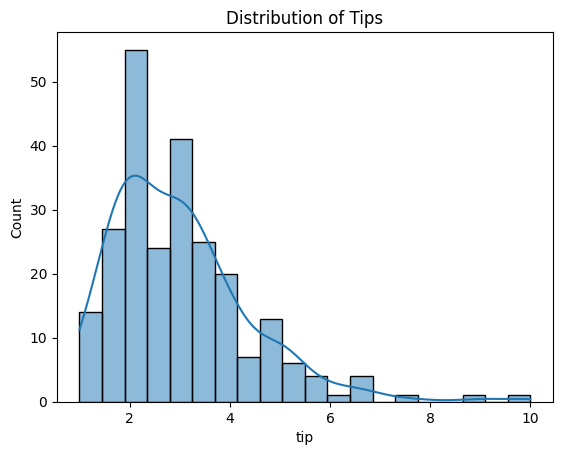

In [3]:
sns.histplot(df['tip'],bins=20,kde=True)

plt.title("Distribution of Tips")
plt.show()

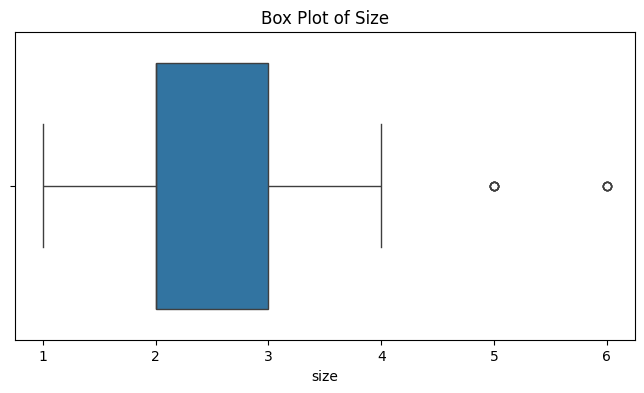

In [4]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['size'])

plt.title("Box Plot of Size")
plt.show()

### 2. Categorical Variable: 

Value Counts

In [5]:
print(df['day'].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


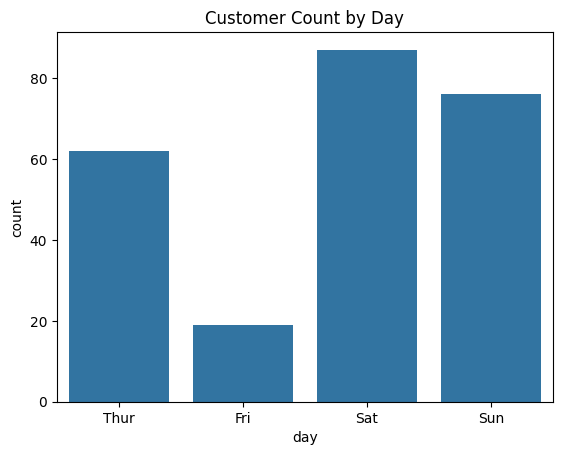

In [6]:
## Count Plot
sns.countplot(x='day',data=df)
plt.title("Customer Count by Day")
plt.show()

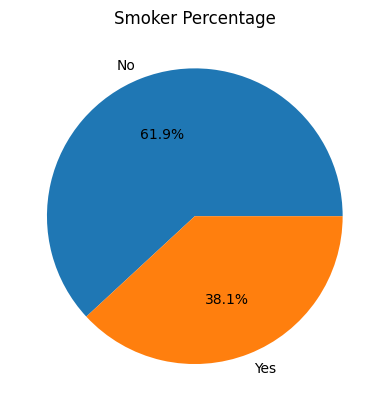

In [12]:
#Pie Chart
df['smoker'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Smoker Percentage")
plt.ylabel("")
plt.show()

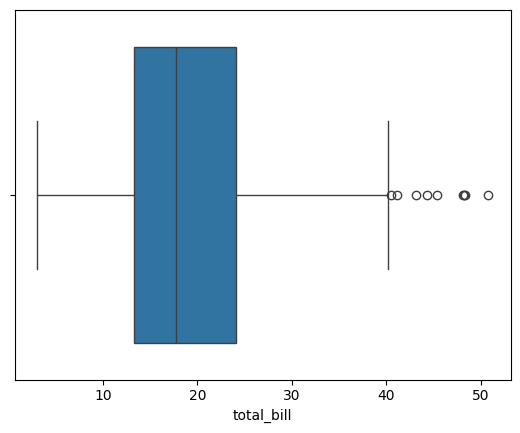

IQR Outliers: 9
Z-score Outliers: 4


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#Load Titanic Dataset
df=sns.load_dataset('tips')

# Box Plot
sns.boxplot(x=df['total_bill'])
plt.show()

# IQR Method
Q1=df['total_bill'].quantile(0.25)
Q3=df['total_bill'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers_iqr=df[(df['total_bill']<lower) | (df['total_bill']>upper)]

print("IQR Outliers:",len(outliers_iqr))

# Z-Score Method
df['total_bill_zscore']=zscore(df['total_bill'])

outliers_z=df[abs(df['total_bill_zscore'])>3]

print("Z-score Outliers:",len(outliers_z))

### Bivariate 
* Bivariate Analysis means analyzing two variables together to understand the relationship between them.
* Bi=Two
* Variate=Variables

#### Types of Bivariate Analysis

| Variable 1 | Variable 2 | Visualization |
|------------|------------|--------------|
| Numerical | Numerical | Scatterplot |
|Categorical | Numerical | Bar Chart |
| Categorical | Categorical | Grouped Statistics/Crosstab

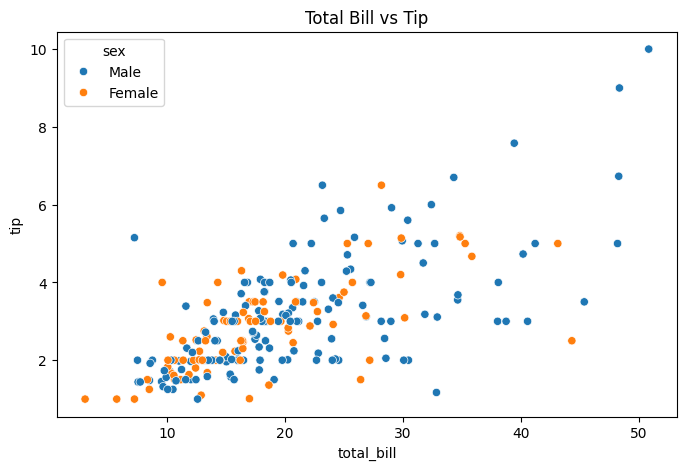

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='sex',
    data=df
)
plt.title("Total Bill vs Tip")
plt.show()

### Correlation

**Pearson Correlation**

In [16]:
corr=df['total_bill'].corr(df['tip'])
print(corr)

0.6757341092113641


### 2. Categorical vs Numerical

#### Day vs Total Bill
* Compare average values across categories.

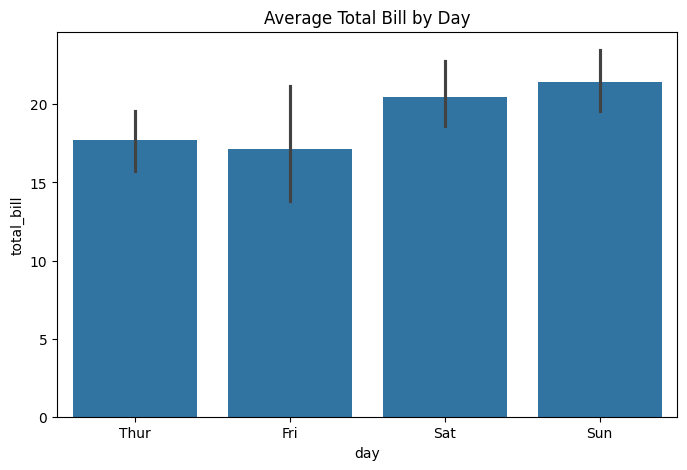

In [17]:
# Bar Chart
plt.figure(figsize=(8,5))

sns.barplot(
    x='day',
    y='total_bill',
    data=df
)

plt.title("Average Total Bill by Day")
plt.show()

In [18]:
# Grouped Statistics
# Mean Bill by Day

print(
    df.groupby('day',observed=False)['total_bill'].mean()
)

# Multiple Statistics
print(
    df.groupby('day',observed=False)['total_bill'].agg(['mean','median','min','max'])
)

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64
           mean  median   min    max
day                                 
Thur  17.682742   16.20  7.51  43.11
Fri   17.151579   15.38  5.75  40.17
Sat   20.441379   18.24  3.07  50.81
Sun   21.410000   19.63  7.25  48.17


### 3.Categorical vs Numerical

### Sex vs Smoker
* Compare frequencies between categories

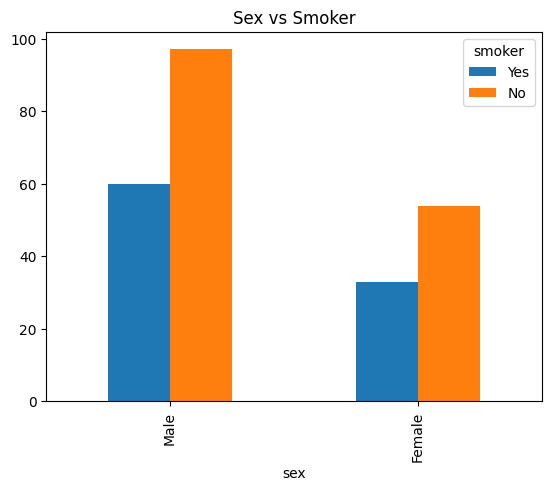

In [19]:
# Bar Chart
pd.crosstab(
    df['sex'],
    df['smoker']
).plot(kind='bar')
plt.title("Sex vs Smoker")
plt.show()

### Multivariate Analysis
* MVA means analyzing three or more variables simultaneously to understand complex relationships and patterns in data.

##### Example
**Instead of Studying**
1. Height alone (Univariate)
2. Height vs Weight (Bivariate)

We Study:
* Height vs Weight vs Age vs Gender
* This is Multivariate Analysis

##### Objectives of Multivariate Analysis
1. Discover hidden relationships
2. Understand interactions among multiple features
3. Detect Clusters and Patterns
4. Support Feature Selection
5. Prepare Data for Machine Learning

### 1. Pairplot

* A Pairplot Compares every numerical feature with every other numerical feature.
* It Automatically Creates:
  1. Scatter Plots
  2. Histograms
  3. Relationship Matrix

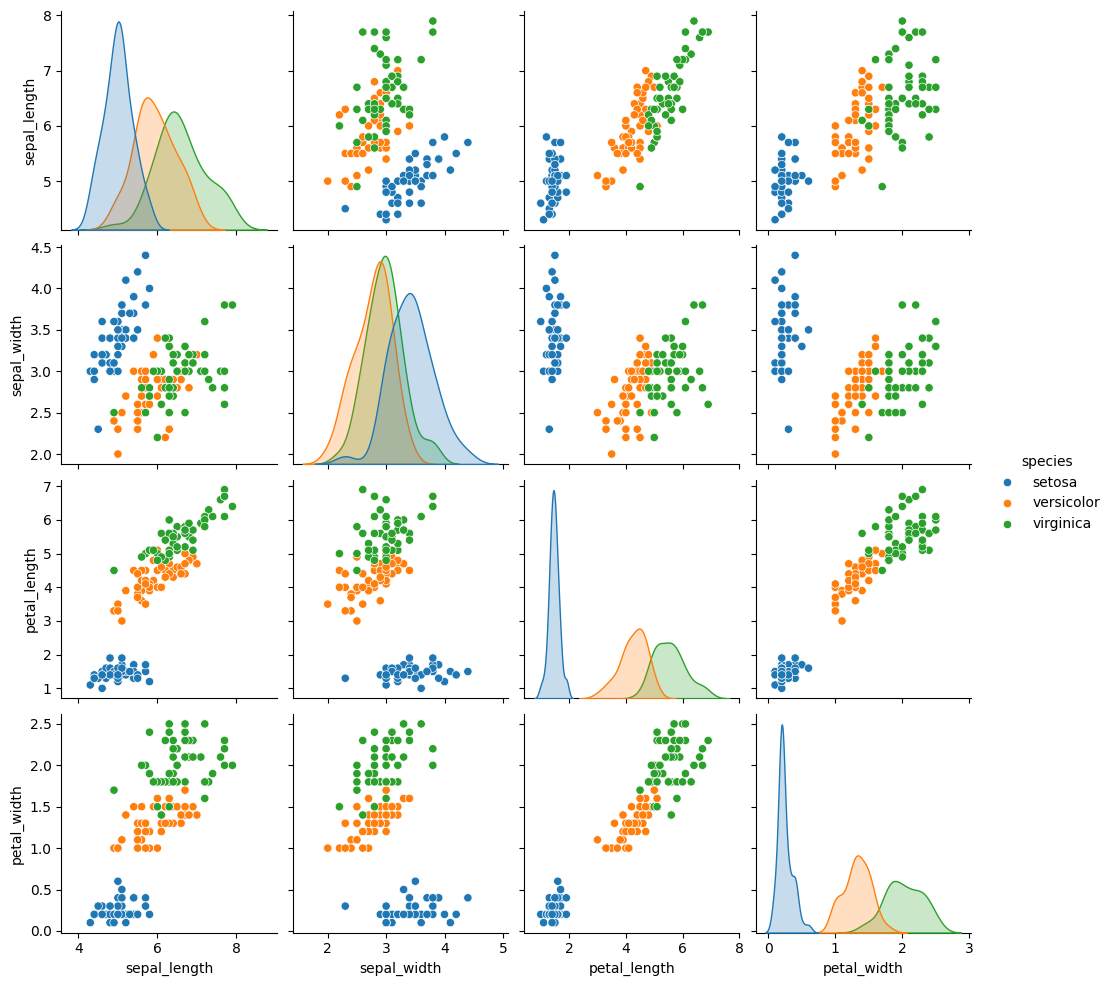

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset("iris")

sns.pairplot(
    df,
    hue='species'
)

plt.show()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 2.Color-Coded Scatter Plot (3rd Dimension)
* A Scatter plot normally shows:
  1. X -> Petal Length
  2. 

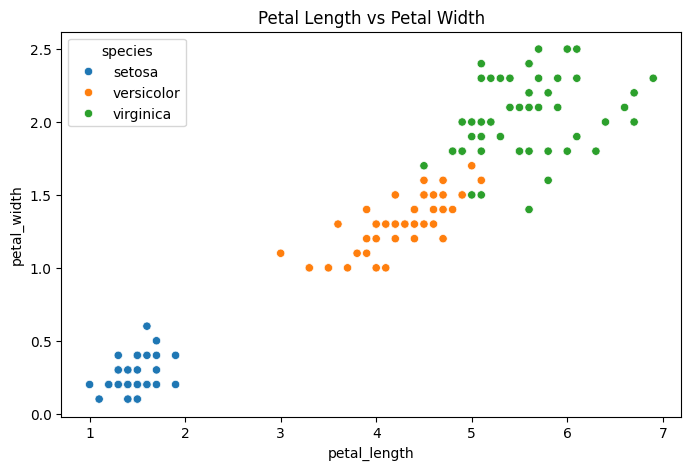

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df
)

plt.title("Petal Length vs Petal Width")
plt.show()

### A Third Variable can be represented using colors.

**Example**
1. X -> Petal Length
2. Y -> Petal Width
3. Color -> Species

### 3D Scatter Plot

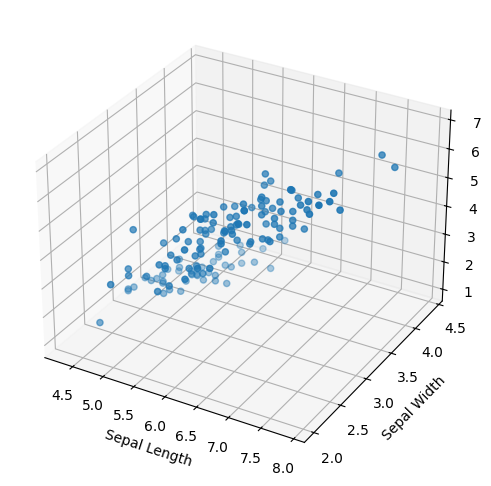

In [23]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection='3d')

ax.scatter(
    df['sepal_length'],
    df['sepal_width'],
    df['petal_length'])

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.show()

#### Correlation Matrix
* A Correlation Matrix shows the correlation between 

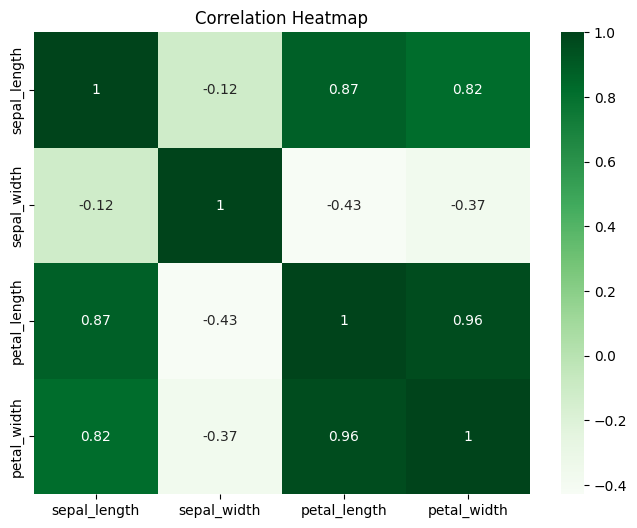

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Greens')
plt.title("Correlation Heatmap")
plt.show()

### VIF (Variance Inflation Factor) for Multicollinearity Detection

**What is Multicollinearity?**
* Multicollinearity occurs when independent variables (features) are highly correlated with each other.

**Example**
* Suppose a house price dataset contains:

1. House Area (sq.ft)
2. Number of Rooms
3. Number of Bedrooms

* These features may contain similar information
* This Creates multicollinearity

#### What is VIF?

* Variance Inflation Factor (VIF) measures how much the variance of a feature is inflated because of its correlation with other features.

| VIF Inflation | Table |
|---------------|-------|
|VIF Value|Interpretation|
| 1 | No Correlation |
| 1-5 | Low Correlation |

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X=df.drop("species",axis=1)
vif=pd.DataFrame()
vif["Feature"]=X.columns
vif["VIF"]=[
    variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]

print(vif)

        Feature         VIF
0  sepal_length  262.969348
1   sepal_width   96.353292
2  petal_length  172.960962
3   petal_width   55.502060


In [29]:
# Suppose we remove petal_length

X_new=X.drop("sepal_length",axis=1)

vif_after=pd.DataFrame()

vif_after["Feature"]=X_new.columns

vif_after["VIF"]=[
    variance_inflation_factor(X_new.values,i)
    for i in range(X_new.shape[1])
]
print(vif_after)

        Feature        VIF
0   sepal_width   5.856965
1  petal_length  62.071308
2   petal_width  43.292574
